In [16]:
from mplsoccer import Pitch, Sbopen
import matplotlib.pyplot as plt

# read data
parser = Sbopen()
df, related, freeze, tactics = parser.event(3857283)

BELGIUM PLAYERS
Not enough pass data for Courtois, skipping.
Not enough pass data for Alderweireld, skipping.
Not enough pass data for Vertonghen, skipping.
Not enough pass data for Castagne, skipping.


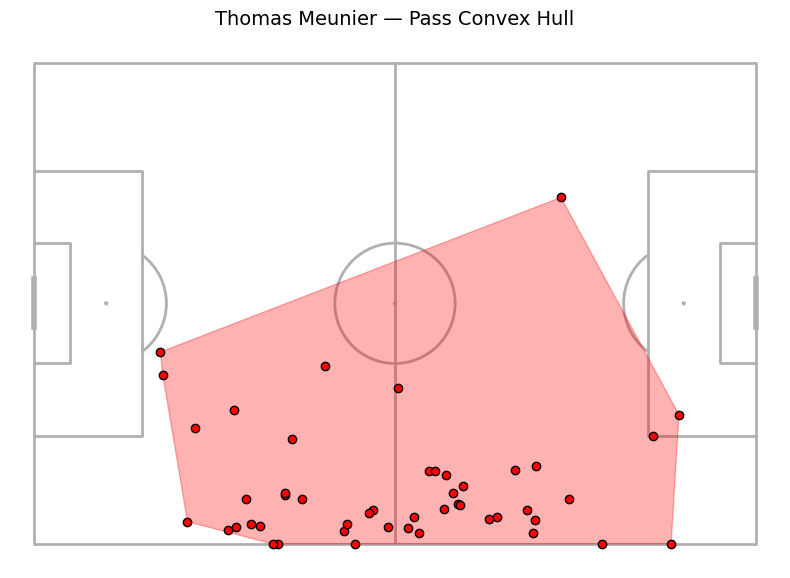

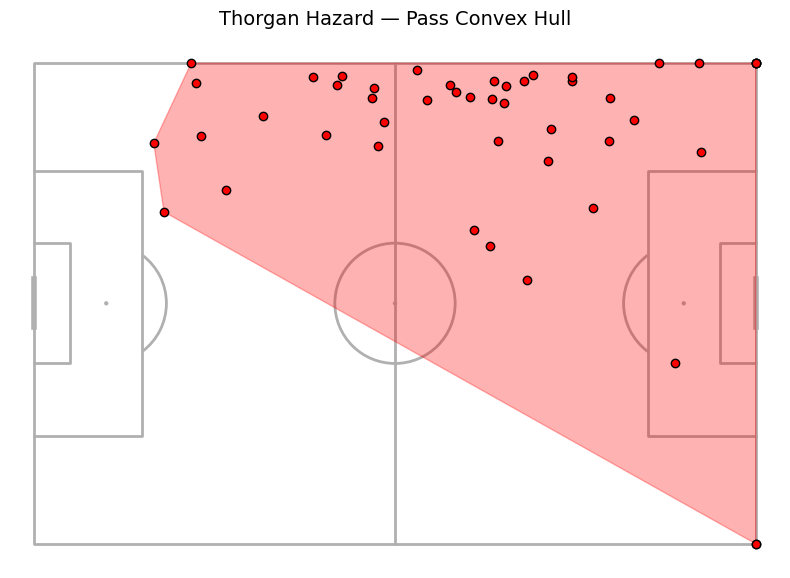

Not enough pass data for Michy Batshuayi, skipping.
Not enough pass data for Onana, skipping.
Not enough pass data for Witsel, skipping.


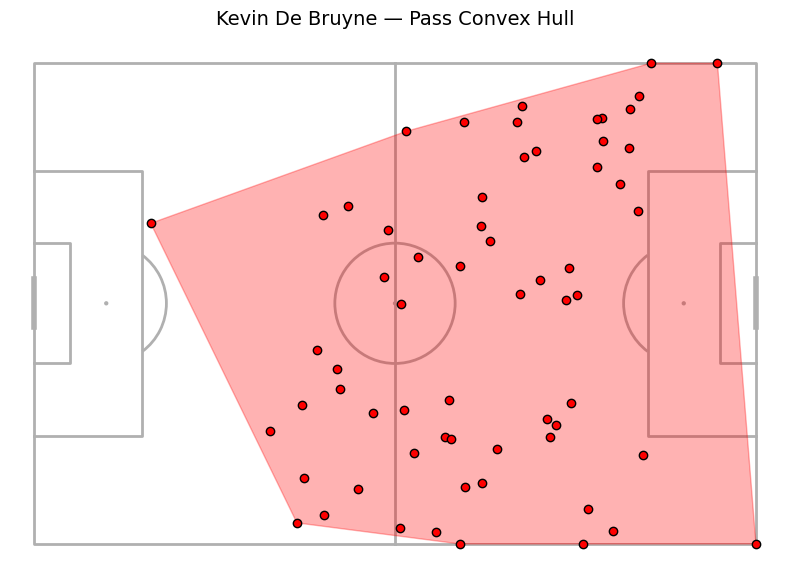

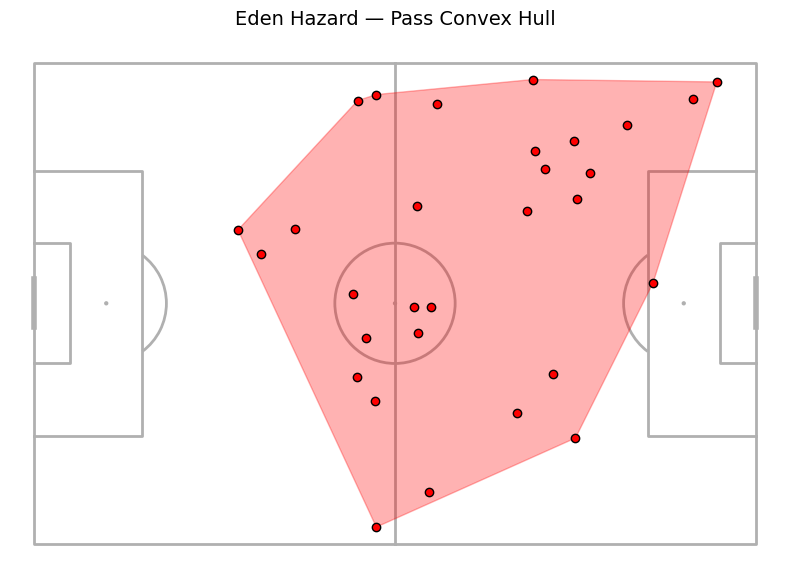

MOROCCO PLAYERS
Not enough pass data for Munir, skipping.
Not enough pass data for Hakimi, skipping.


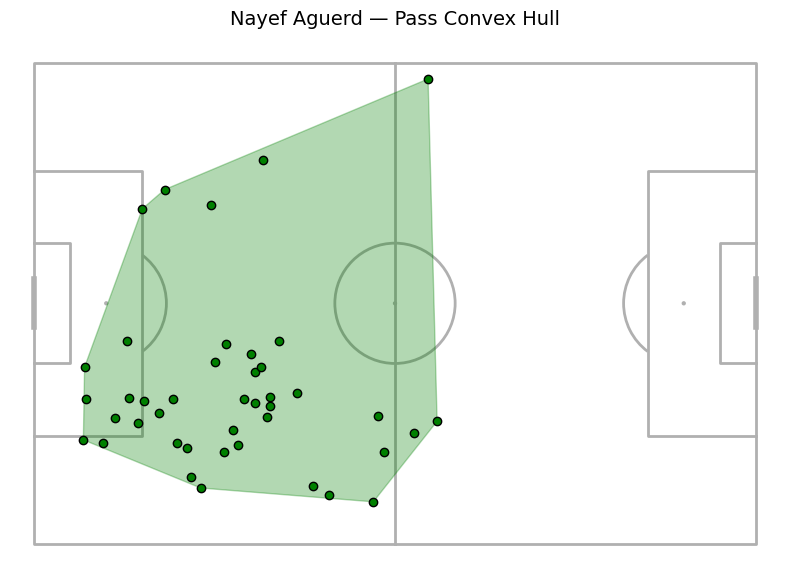

Not enough pass data for Saïss, skipping.
Not enough pass data for Mazraoui, skipping.
Not enough pass data for Amallah, skipping.
Not enough pass data for Amrabat, skipping.
Not enough pass data for Ounahi, skipping.
Not enough pass data for Ziyech, skipping.
Not enough pass data for Boufal, skipping.


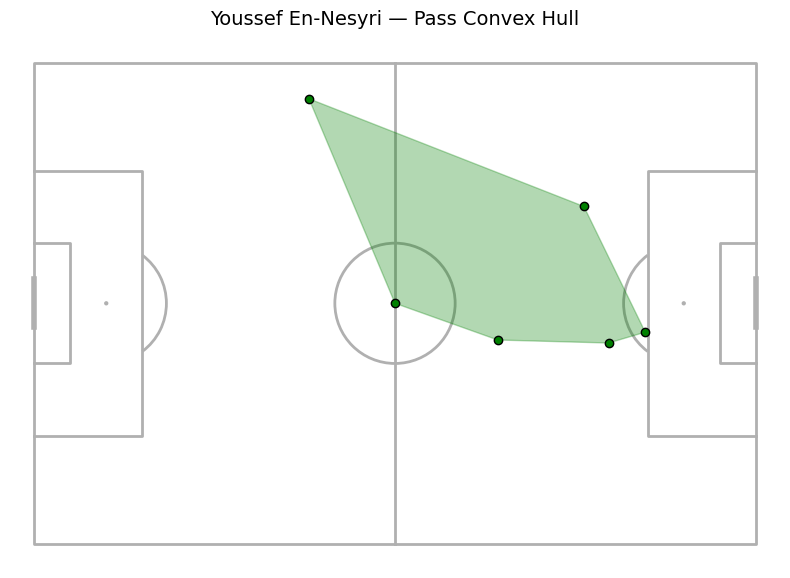

In [17]:
belgium_players = ['Courtois', 'Alderweireld', 'Vertonghen', 'Castagne', 'Thomas Meunier',
                   'Thorgan Hazard', 'Michy Batshuayi', 'Onana', 'Witsel', 'Kevin De Bruyne', 'Eden Hazard']

morocco_players = ['Munir', 'Hakimi', 'Nayef Aguerd', 'Saïss', 'Mazraoui',
                   'Amallah', 'Amrabat', 'Ounahi', 'Ziyech', 'Boufal', 'Youssef En-Nesyri']

def plot_player_hull(df, player_name, color):
    player_df = df[(df['player_name'] == player_name) & (df['type_name'] == 'Pass')].copy()  # ← fixed

    if len(player_df) < 3:
        print(f"Not enough pass data for {player_name}, skipping.")
        return

    pitch = Pitch()
    fig, ax = pitch.draw(figsize=(8, 6))
    ax.set_title(f'{player_name} — Pass Convex Hull', fontsize=14, pad=10)

    hull = pitch.convexhull(player_df.x, player_df.y)
    pitch.polygon(hull, ax=ax, edgecolor=color, facecolor=color, alpha=0.3)
    pitch.scatter(player_df.x, player_df.y, ax=ax, edgecolor='black', facecolor=color)

    plt.tight_layout()
    plt.show()

# ── Belgium players ───────────────────────────────────────────────────────────
print("=" * 40)
print("BELGIUM PLAYERS")
print("=" * 40)
for player in belgium_players:
    plot_player_hull(df, player, color='red')

# ── Morocco players ───────────────────────────────────────────────────────────
print("=" * 40)
print("MOROCCO PLAYERS")
print("=" * 40)
for player in morocco_players:
    plot_player_hull(df, player, color='green')